---
format: 
  html:
    grid: 
      sidebar-width: 0px
      body-width: 10000px
---







<style>
body {
text-align: justify}
</style>

:::{.hero-banner}
# Modelling

:::





# Machine learning models

In the first part of the modeling section, a range of machine learning models from simple to complex will be presented. Before doing so, however, a comprehensive introduction to modeling topics will be provided.

## Regression vs. Classification
This section covers `supervised learning` which is one of two primary approaches in Machine Learning, with the other being `unsupervised learning`.
Supervised learning is when the true class of each observation is known, and can be used to train a model recognizing patterns among the classes.
Then some data without class labels are presented to the model and it is the model's task to provide the correct labels to the data.
<!-- Recall the last section where training a test sets of the data was introduced. -->
<!-- In supervised learning are training data the data with the labels and the test set is the data without labels, where the model have to predict the labels. -->

Machine learning models have two primary problem types, either `regression` dealing with the prediction of continuous values, or `classification` dealing with discrete outcomes.


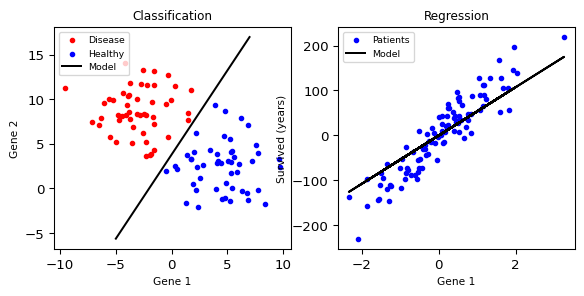

In [1]:
#| fig-align: center


# code stems from: https://dev.to/petercour/machine-learning-classification-vs-regression-1gn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs, make_regression
from sklearn.svm import LinearSVC, LinearSVR
import warnings
warnings.filterwarnings("ignore")

title_size = 16
axis_label_size = 12
params = {'legend.fontsize': 7,
          'figure.figsize': (7, 3),
          'axes.labelsize': 8,
          'axes.titlesize': 9,
          'xtick.labelsize': 10,
          'ytick.labelsize': 10}
plt.rcParams.update(params)

def make_classification_example(axis, random_state):
    X, y = make_blobs(n_samples=100, n_features=2, centers=2, cluster_std=2.7, random_state=random_state)
    axis.scatter(X[y == 0, 0], X[y == 0, 1], color="red", s=10, label="Disease")
    axis.scatter(X[y == 1, 0], X[y == 1, 1], color="blue", s=10, label="Healthy")

    clf = LinearSVC().fit(X, y)

    # get the separating hyperplane
    w = clf.coef_[0]
    a = -w[0] / w[1]
    xx = np.linspace(-5, 7)
    yy = a * xx - (clf.intercept_[0]) / w[1]

    # plot the line, the points, and the nearest vectors to the plane
    axis.plot(xx, yy, 'k-', color="black", label="Model")
    ax1.tick_params(labelbottom='off', labelleft='off')
    ax1.set_xlabel("Gene 1")
    ax1.set_ylabel("Gene 2")
    ax1.legend()

def make_regression_example(axis, random_state):
    X, y = make_regression(n_samples=100, n_features=1, noise=30.0, random_state=random_state)
    axis.scatter(X[:, 0], y, color="blue", s=10, label="Patients")

    clf = LinearSVR().fit(X, y)
    axis.plot(X[:, 0], clf.predict(X), color="black", label="Model")
    ax2.tick_params(labelbottom='off', labelleft='off')
    ax2.set_xlabel("Gene 1")
    ax2.set_ylabel("Survived (years)")
    ax2.legend()

random_state = np.random.RandomState(42)
f, (ax1, ax2) = plt.subplots(ncols=2)
ax1.set_title("Classification")
make_classification_example(ax1, random_state)
ax2.set_title("Regression")
make_regression_example(ax2, random_state)
plt.show()

<!-- >>>>>>> webpage-quarto -->
<!-- **Devnote: Make a option where people can look at both R code and Python code** -->

Regression is concerned with predicting a continuous outcome.
Regression is a task where some feature variables is used to train a model to predict some target variable. It could be anything from prediction of house priced based on some relevant features, to prediction of blood pressure on some features. Classification is about predicting which feature variable fits best to some target variable categorise. This also means that it is a discrete value which will be predicted. It can be binary categorise or multiclass categorise. Essentially, this task involves assigning a probability value to each class. Examples of these binary events are most often positive/negative – or true/negative. These scenarios can be anything from getting approved for a loan to a medical diagnosis (Hastie et al. 2001:9-11). In terms of healthcare application is the idea that, a model have been trained with a lot a of clean high quality data and this model can be feed some information (features) about a patient, which can be used for some prediction (providing a label). So if a patient have some different values rising, like blood pressure, body temperature, etc. The model might suggest that it is a sign of some illness coming up. Another example is from the **motivational example** from the introduction of the this course regarding the decision of providing SACT for palliative patients. Such a model could assist the clinicians in making the decision of providing SACT or not. The doctor would provide the models with relevant values of the patients and the model would provide a risk score, which is a significant consideration to include in the decision process.


## Classification problems
The methods and terminology is introduced in the context of two-class classification problems, but similar terms exist for multi-class classification problems.

As we are only considering supervised learning, it is possible to tell when the model predictions are wrong, but often just counting the raw amount of misclassifications is misleading.
For example, if we have 10 misclassifications out of 5000 total data points, the model is better than if we had only 100 data points.
In order to make the models' performance comparable, the model performance metrics are introduced.

### Model performance metrics

Consider the classification illustrated in the figure below, classified using a simple linear boundary, where points with a green outline are correctly predicted, and opposite for points with a red outline.

<div style="text-align: left;">
  <img src="../images/class_problem.png" alt="Image" style="margin-bottom: 15px; width: min(400px, 100%);">
</div>

This is a typical two-class classification problem, with a positive and a negative class.
The linear boundary visualizes the divide in prediction regions, with each class predicted on each side of the boundary.
This divide motivates the terms

- True Positives (TP): Points belonging to the positive class, predicted as the positive class.
- True Negatives (TN): Points belonging to the negative class, predicted as the negative class.
- False Positives (FP): Points belonging to the negative class, predicted as the positive class. This is also known as the [type I error.](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors)
- False Negatives (FN): Points belonging to the positive class, predicted as the negative class. This is also known as the [type II error.](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors)

All of this can be aggregated in a [confusion matrix](https://medium.com/@nikitamalviya/confusion-matrix-870739a1ec31), illustrated in the figure below.

<div style="overflow: hidden;">
  <img src="../images/iamconfusion.png" alt="Image" style="margin-bottom: 15px; margin-top: -30px; width: min(400px, 100%);">
</div>

A simple way to measure the performance classification problems, is to consider the accuracy of the model, given by
$$\text{Accuracy} = \frac{TP+TN}{FP+TP+TN+FN}$$
This is relevant, when both classes are equally important.
Often, this is not the case, such as in forensic sciences, where type I errors could point the evidence to another person, or as in the motivational example, where type II errors result in lower life quality just before death.
For more examples of prioritization of type I and II errors, see  [here.](https://baotramduong.medium.com/binary-classification-error-type-i-vs-error-type-ii-6a444fb22676).
As such, it is important to consider the metrics sensitivity, precision, and specificity, given by

\begin{align}
  \text{Sensitivity} &= \frac{TP}{TP+FN}\\
  \text{Specificity} &= \frac{TN}{TN+FP}\\
  \text{Precision}   &= \frac{TP}{TP+FP}
\end{align}

The sensitivity metric, also known as recall, considers all points belonging to the positive class in the data set, and specificity is the complement to this, considering only the points belonging to the negative class.
In contrary, the precision metric considers the model's performance for predicting the positive class.

Combining sensitivity and precision, gives the $F_1$ score, usable to evaluate the model's correct predictions across the entire data set.
It is given by
$$F_1\text{ score} = \frac{2\cdot\text{Precision}\cdot\text{Sensitivity}}{\text{Precision} + \text{Sensitivity}} = \frac{TP}{TP + \frac{1}{2}(FP + FN)}$$


It is important to note, that this metric [does not work well when there is a class imbalance in the dataset,](https://www.v7labs.com/blog/f1-score-guide) motivating the introduction of the [$F_\beta$ metric](https://machinelearningmastery.com/tour-of-evaluation-metrics-for-imbalanced-classification/), given by <!-- Er ikke med i slides, men opgaven spørger efter hvilken metric man vil bruge når nu datasættet er ubalanceret, og den passer godt -->
$$F_\beta\text{ score} = \frac{(1 + \beta^2)\cdot\text{Precision}\cdot\text{Sensitivity}}{\beta^2\cdot\text{Precision}+\text{Sensitivity}}$$
Different values for $\beta$, changes which classification the metric prioritizes, i.e. for $\beta$s smaller than 1, the positive class is more important, and vice versa for $\beta$s larger than 1. Typically $\beta$ equal to 0.5 and 2 is used.

For the classification in the figure above, the metrics have the following values:

| Accuracy | Sensitivity | Specificity | Precision | $F_1$ score |
|:---------|:------------|:------------|:----------|:------------|
| 0.85     | 0.86        | 0.84        | 0.83      | 0.84        |

For more on all of these metrics, click [here](https://medium.com/@eren.soykok/model-evaluation-metrics-3b6c4bf91e6b).

The value of the metrics lie between 0 and 1, and the closer to 1, the better the model is at predicting the data.
However, consider the following figure.

<div style="overflow: hidden;">
  <img src="../images/overfitting.png" alt="Image" style="margin-bottom: 15px; width: min(800px, 100%);">
</div>

The model performance metrics for the classification to the right are all equal to 1 for the data it is trained on, but when used on new data, it is seen that a simpler model is better.
This is because the model used for the right classification is too specific, which makes it generally not usable in practice.
The problem of wanting a model that captures the right patterns in the predictors, but not so much that it becomes too specific, is known as the bias-variance trade-off. (Hastie et al. 2001:33-38)

### Bias-variance trade-off
Bias is a term referring to the error that stems from using too simple a model to approximate a more complicated real-life problem.
For example, the logistic model is a very simple model, as it is based on a linear model, and it is rarely the case that any real-life problem has a completely linear relation between the response variable and the predictors.
This means that there is some pattern in the data, that a logistic model is not able to catch, i.e. the bias.
The term of using too simple a model for the data is generally known as **underfitting**.
Conversely, the variance is referring to the error that stems from using too flexible a model.
Here it is possible to create a model too specific to the training data, known as **overfitting**.

In the figure above, the left classification is from an underfitted model, whereas the right classification is from an overfitted model.

You want to pick the model type and complexity, that results in no overfitting or underfitting of the data, which is why it is called a trade-off.
To find this trade-off, you can train the model on some of your data, and test its applicability on new data by using the data you left out, as introduced in the data management section. <!-- #### REF HER #### --> 

With these terms in place, the first of the machine learning models is introduced.


## Logistic regression 
Different models can be used for classification, but a popular model for classification is the logistic regression model. Logistic regression is a supervised linear model that is used in scenarios with categorical outcomes. One of the strengths of logistic regression is the strong explainability, which means that the results can be understood and interpreted to a high degree compared to other models and it is a good candidate for a baseline model, if benchmarking multiple models to find the best risk prediction model.

Logistic regression is a linear model which outputs a probability score instead of a direct linear combination. To express this mathematically:

$$\hat{p} = \sigma(\theta^T \mathbf{x})$$

In general, linear models aim to find the parameters $\theta$ (also called beta or weights) that optimize the model. The probability function shown in the formula, $\sigma$, transforms the linear combination into a probability between 0 and 1. Mathematically the sigmoid function is defined as:

$$\sigma(t) = \frac{1}{1 + \exp(-t)}$$

As $t$ approaches positive infinity, the sigmoid function approaches 1, and as $t$ approaches negative infinity, the sigmoid function approaches 0.

To transform linear combinations into probabilities, the logarithm of the odds ratio is used. This converts the output of a linear model into a probability value between 0 and 1 by applying the logistic function. The logarithm of the odds ratio can be expressed as:

$$ \log \left( \frac{p(x)}{1-p(x)} \right) = \beta_0 + \beta_1 x $$
<!-- Kunne overveje at lave denne til en theta^T x, ligesom over-->

Where:

- $p(x)$ is the probability of the outcome
- $\log \left( \frac{p(x)}{1-p(x)} \right)$ is the logarithm of odds function (logit)
- $\beta_0$ is the bias parameter
- $\beta_1$ is the weight parameter
- $x$ is the feature variable

The sigmoid function creates an S-shaped curve that pushes the data points toward either 0 or 1, which facilitates binary classification. The *linear* part of the model creates the decision boundary, which, combined with a threshold determines whether a data point belongs to class 0 or class 1.
Normally, the threshold is set at 0.5, but it can be changed in accordance with the task and if there is an emphasis on either type I - or type II errors.
The sigmoid function and the dynamic between threshold and decision boundary can be seen in the figure below.

<div style="text-align: center;">
  <img src="../images/Log_reg_decision_boundary.PNG" alt="Image" style="margin-bottom: 15px; width: min(750px, 100%);">
</div>
The visualization stems from this [mini course](https://ds100.org/course-notes-su23/logistic_regression_2/logistic_reg_2.html).

Practically, logistic regression is trained using numerical optimization, which essentially means that the optimal parameters are found through 'trial-and-error' where the models parameters are shifted and the model predictions are compared to the true values, repeated iteratively until the optimal parameters are found.
The optimization method can be a simple gradient descent or a more sophisticated algorithm.
Learn more about optimization algorithms for finding the optimal parameters in logistic regression [here](https://medium.com/@arnavr/scikit-learn-solvers-explained-780a17bc322d).

It is important to measure how much of an improvement is made when changing the parameters, as such an evaluation function is used.
This is what known as a *loss function* (or cost function) which quantifies the model error.
There are many different types of loss function, but for the logistic regression, a well known loss function is the **log loss** (which is also known as Cross Entropy loss), given by

$$
\sum_{i\mid y_i=1} \log\big(1-p(x_i)\big) + \sum_{i\mid y_i=0} \log\big(p(x_i)\big)
$$
The general idea of this loss function is that it measures the distance between the predictions and the true labels.
The magnitude of this distance directly impacts the loss.
Predictions that are both incorrect and made with high confidence are penalized more severely compared to incorrect predictions made with lower confidence.
The goal of the optimizer is to minimize the loss function with respect to $\beta$ (implicitly present via $p(x_i)$), and it keeps adjusting the values, until the loss no longer improves significantly.

When trying to predict an outcome with many predictor variables, it becomes a challenge if the number of these potential predictors (denoted by "p") surpass the number of data points in the dataset (denoted by "n").
To manage this imbalance effectively, regularization methods can be used to create a sparse model, i.e. a model with only a few important features with the rest removed (Hastie et al. 2001:649-664).
Regularization is not only needed when $p > n$ but also to reduce the overfitting of a model, a problem frequently occurring in various complex models.

One of the most well-known and used regularization techniques is Ridge regression (L2):
$$
\lambda\sum_{j=1}^{p} \beta_{j}^{2}
$$
The idea is to penalize the weights of the model and in the case of ridge, it would be with the sum of the squared coefficients, times a tuning parameter $\lambda$ to decide the strength of the regularization.
The benefit of Ridge regression is that it pushes the weights towards zero, relative to the size.
This means that large weights are heavily penalized and small weights rarely hit zero.

It is also possible to penalize the weight using the absolute value instead of the squared sum, this would mean that all weights are treated equally.
This is called the least absolute shrinkage and selection operator (LASSO) or L1, and is given by
$$
\lambda\sum_{j=1}^{p} |\beta_j|
$$
This type of regularization is especially powerful in terms of regularizing the model, but also to do feature selection. As the weight are penalized with a absolute rate, the weights are able to shrink to zero.
This means that small weights that cause more noise than accuracy, can be removed from the model.

These terms are added to the loss function when minimizing, i.e. with LASSO regularization, the optimization problem becomes
$$
\min_{\beta}\sum_{i\mid y_i=1} \log\big(1-p(x_i)\big) + \sum_{i\mid y_i=0} \log\big(p(x_i)\big) + \lambda\sum_{j=1}^{p} |\beta_j|
$$

The effects of LASSO and Ridge can be visualized as follow:
<div style="text-align: center;">
  <img src="../images/L1L2.PNG" alt="Image" style="margin-bottom: 15px; width: min(750px, 100%);">
</div>

Where it can be seen that Ridge is wider compared to LASSO and LASSO is taller compared to Ridge. The visualization is a illustration of the ridge regression ability to reduce large weights at a large rate, where LASSO have to ability to reduce weights to zero. **Provide a better explanation**

In some cases it can be an advantage to combine the power of Ridge and Lasso, while being able to customize the weighting of the two methods. To provide a flexible approach to balance between Ridge - and Lasso regression can a method called **Elastic net** be applied, which have a hyperparameter for having most emphasis on LASSO or Ridge. Elastic net can mathematically be expressed like:
$$
\min_{\beta} \frac{1}{N} \sum_{i=1}^{N} l(y_i, \beta, x_i) + \lambda \sum_{j=1}^{p} (\alpha\beta_j^2 + (1 - \alpha)|\beta_j|)
$$

Where $\lambda$ still is the strength hyperparameter and $\alpha$ is the mixture parameter. Alpha goes between 0.0 and 1.0, where the weight is going from Ridge to LASSO.

Now there should be a understanding of the basic behind creating a linear model like logistic regression and how to regularize the parameters for better performance with Ridge, LASSO and Elastic net.

In the next part, will a more flexible but also very powerful model be presented. The **Classification Trees**.

## Decision Trees
The Decision trees, are non-parametric models that split data iteratively, which means that the model does not assume any structure, but let the data determine the structure of the model. The models finds the structure by examining the data through iteration. Decision trees are versatile machine learning models, which means they can be used for regression and classification tasks. When the trees are used for making prediction, it does it by deciding on nodes and leaf nodes where the idea is to us recursive binary splitting. The model will keep splitting the data into groups until some criteria are met. In more details are the idea that there is a `root` node, which is the first variable used for splitting. The splitting is a true/false process, where there is some criteria for the splitting, like age above 65, then the tree branches out to a new who have the best interaction with the two groups so there might be the best splitting criteria for people under 65 years of age, which is their weight and their might be a best splitting criteria for the people above 65 of age, which is their weight. From that point can the two `branches` nodes be splitted into the finale four nodes, which is called the `leaf` nodes. The decision on which variable to pick for a branch is based on the interaction score between the variables used in the tree and the target variable. The measure used to determine the branching is the Gini index. The gini index is a measure for the nodes, where the *impurity* is measured, where the ratio of classes in each node is the measure of impurity. If a node contains 50/50 of two classes of the target variable (like having benign or malignant cancer) would mean that the node in very impure and would have a gini index equal to 0.5. If a node had 100% malignant cases, when the node would be pure and there would be a gini index equal to 0. The gini index can be expressed mathematically as:
$$
\text{Gini index} = 1 - \sum_{k=1}^{n} p_{i,k}^2
$$
where $p_{i,k}$ is the proportion of samples that belong to class $k$ at node $i$.
The most important hyperparameter is the maximum depth of the tree which is the maximum amount of branches between the root node and the leafs. By restricting the depth, it prevent the tree from becoming too complex and start overfitting the data. Finding the optimal depth is a iterative process.
As mentioned regarding the regularization of models, it is also significant for the generalization of the decision trees restricted on the training data. Decision trees have a selection of unique hyperparameters, where max depth is one of them. Another regularization method is to decide how many samples should be in each node. The regularization techniques reserved for decision trees are called **pruning**.
For regression tasks are the decision trees similar in terms of building a tree and splitting the data. However, instead of using Gini index, the trees used for regression tasks uses Mean Squared Error (MSE). More information about Classification and Regression Trees can be found [here](https://en.wikipedia.org/wiki/Decision_tree_learning)

<div style="text-align: center;">
  <img src="../images/Decision_trees.PNG" alt="Image" style="margin-bottom: 15px; width: min(750px, 100%);">
  <div>
  **Note**: Decision notes are <u>Blue</u> and the Leaf notes are <u>Green</u>.
  </div>
</div>

Although decision trees are powerful models on their own, they are still limited by instability due to the model being sensitive to changes in the data. Small variations in the training dataset can lead to completely different tree structures, as the greedy splitting algorithm makes locally optimal decisions at each node. This high variance means that decision trees may create overly complex structures that capture noise rather than underlying patterns.

To address these issues, can **[ensempling](https://en.wikipedia.org/wiki/Ensemble_learning)** be added to the trees and create methods like **Random forest** or **Gradient boosting**.

## Ensemble learning methods

Ensemble methods combine multiple models to solve problems better than any single model could. They work by merging several weak learners into one strong predictor. This is also known as *wisdom of the crowd*.

### Bagging

Bagging (Bootstrap Aggregating) builds many independent models from random data samples and averages their predictions. The aggregation function is most often the statistical mode, which is the most frequent prediction. Each model trains on different data subsets created through random sampling with replacement. It is called **pasting** when the sampling is performed *without* replacement.

This approach reduces variance and helps avoid overfitting. The classic example is the basic bootstrap ensemble, where multiple decision trees make predictions that are then combined through voting (for classification) or averaging (for regression).

### Random Forest

[Random Forest](https://en.wikipedia.org/wiki/Random_forest) extends bagging by adding another layer of randomness. Not only does it sample data points, but it also samples features when building each tree.

When growing trees, Random Forest considers only a random subset of features at each split point. This makes the trees more diverse and helps them capture different patterns in the data, leading to better overall performance and robustness against noise.

### Gradient Boosted Trees

Unlike bagging methods that build independent models, boosting builds models sequentially. Each new model focuses on fixing the mistakes of combined previous models. There are many boosting methods, but one of the more popular ones are [Gradient Boosting](https://en.wikipedia.org/wiki/Gradient_boosting)

Gradient Boosted Trees add new weak learners (typically shallow decision trees) that target the errors made by existing trees. Each step minimizes the loss function's gradient, hence the name "gradient" boosting.

This sequential improvement process creates highly accurate models but requires tuning hyperparameters to avoid overfitting.

## Neural Networks 

### Train neural networks

### Hyperparameters for Neural Networks
Hyperparameters control how neural networks learn. They are set before training begins and greatly affect results.
Key hyperparameters include:

- Learning rate: Controls how much weights change with each update

- Network structure: How many layers and nodes to use

- Batch size: How many examples to process before updating weights

- Regularization strength: How strongly to prevent overfitting

- Activation functions: Which mathematical operations transform data between layers

Finding the right hyperparameters often requires systematic testing. Small changes can potentially improve or harm performance, significantly. Due to tuning process being time consuming, there can be used different hyperparameter search algorithms to try a wide range of hyperparamaters, automatically.
The choice of hyperparameters determines what the network can learn and how well it will perform on new data.


# Model training

In this part of the section, **osv osv**


## Loss Functions
As 

### Binary cross entropy
### Log likelihood
### AUC metrics

## Hyperparameters Optimization
### Logistic Regression with Elastic Net Regularisation
### Random forest optimization
### Neural Network hyperparameters
## Hyperparemeters optimization
### Grid search
### Random search
### Bayesian optimization


# Exercises
## Modelling
In this workshop you will train and test at least one prediction model based on the datasets you prepared in Workshop 1 (in case you did not succeed with Workshop 1, a prepared data set is available on PhD Moodle under Day 2/Workshop 2. In this dataset there is a variable called split, indicating which split the observation belongs too). You will have a data set for training the model parameters (“training set”), one for evaluating a model fit on the training data while tuning hyper parameters (“validation set”), one to train a calibration model (“calibration set”), and one for final test of model performance (“test set”).
Go through the following steps:
1)	Choose a performance metric for final test of model performance (is there class imbalance in your data?)
2)	Choose a model to train (e.g., logistic regression with elastic net or random forest). What parameters and hyper parameters does the model have?
3)	Train model and tune hyper parameters.
4)	How is the predictive performance of your trained model in the test set? Have a look at the confusion matrix – did we predict both positive and negative outcomes well?
5)	Train a calibration model. How well is the model calibrated, considering the test set?



## Reference

[^1]: https://dev.to/petercour/machine-learning-classification-vs-regression-1gn